# tblastn Truth Breakdown

This notebook writes all generated artifacts to `outputs/`.

## Purpose

Force tblastn lifting on annotated records, then classify why predictions do or do not match ground truth.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from app.validation._shared.validation_utils import *

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
DATASETS = [
    ('PRRS', DATA / 'PRRS_ref_test.gb', CROSS_CHECK / 'PRRS_100seq_anno.gb'),
    ('FMD', DATA / 'FMD_ref_test.gb', CROSS_CHECK / 'FMD_100seq_anno.gb'),
]

frames = []
summaries = []
for virus, ref_path, query_path in DATASETS:
    df, summary = run_tblastn_against_truth(virus, ref_path, query_path, OUTPUT_DIR / virus.lower())
    frames.append(df)
    summaries.append(summary)

tblastn_df = pd.concat(frames, ignore_index=True)
tblastn_summary = pd.concat(summaries, ignore_index=True)
tblastn_df.to_csv(OUTPUT_DIR / 'tblastn_vs_truth.tsv', sep='\t', index=False)
tblastn_summary.to_csv(OUTPUT_DIR / 'tblastn_summary.tsv', sep='\t', index=False)
tblastn_summary

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,900,618,714,0.8244,68.67,79.33
1,FMD,tblastn,1176,1110,1153,0.9927,94.39,98.04


In [3]:
failure_modes = (
    tblastn_df.groupby(['virus', 'failure_mode'])
    .size()
    .reset_index(name='count')
    .sort_values(['virus', 'count'], ascending=[True, False])
)
failure_modes.to_csv(OUTPUT_DIR / 'tblastn_failure_modes.tsv', sep='\t', index=False)
failure_modes

,virus,failure_mode,count
1,FMD,Correct,1110
0,FMD,Boundary offset,43
5,FMD,Wrong coords,19
2,FMD,Not in truth,2
3,FMD,Not lifted,1
4,FMD,Possible overlap,1
8,PRRS,Correct,618
10,PRRS,Possible overlap,124
7,PRRS,Boundary offset,96
11,PRRS,Wrong coords,34


In [4]:
by_gene = summarize_comparison(tblastn_df, ['virus', 'pred_name'])
by_gene.to_csv(OUTPUT_DIR / 'tblastn_per_gene.tsv', sep='\t', index=False)
by_gene.sort_values(['virus', 'coord_pct']).head(30)

,virus,pred_name,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,FMD,2A,98,73,82,0.9677,74.49,83.67
4,FMD,3B,98,95,96,0.9863,96.94,97.96
3,FMD,3A,98,97,97,0.9974,98.98,98.98
8,FMD,VP1,98,80,97,0.9882,81.63,98.98
9,FMD,VP2,98,97,97,0.9968,98.98,98.98
10,FMD,VP3,98,97,97,0.9898,98.98,98.98
11,FMD,VP4,98,97,97,0.9898,98.98,98.98
1,FMD,2B,98,98,98,1.0000,100.00,100.00
2,FMD,2C,98,98,98,1.0000,100.00,100.00
5,FMD,3Cpro,98,96,98,0.9996,97.96,100.00


In [5]:
review_cases = tblastn_df[tblastn_df['failure_mode'] != 'Correct'].copy()
review_cases = review_cases.sort_values(['virus', 'failure_mode', 'record_id', 'pred_name'])
review_cases.to_csv(OUTPUT_DIR / 'tblastn_review_cases.tsv', sep='\t', index=False)
review_cases.head(50)

,virus,record_id,method,pred_name,source_name,pred_start,pred_end,strand,status,coverage,...,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
904,FMD,AY687333.1,tblastn,VP1,None,3251.0,3880.0,+,ok,1.0000,...,VP1,3251.0,3886.0,VP1,0.9906,0.9906,True,True,False,Boundary offset
916,FMD,AY687334.1,tblastn,VP1,None,3250.0,3876.0,+,ok,1.0000,...,VP1,3250.0,3882.0,VP1,0.9905,0.9905,True,True,False,Boundary offset
1289,FMD,DQ533483.2,tblastn,2A,None,3893.0,3943.0,+,ok,0.9444,...,2A,3890.0,3943.0,2A,0.9444,0.9444,True,True,False,Boundary offset
941,FMD,DQ989304.1,tblastn,2A,None,3934.0,3984.0,+,ok,0.9444,...,2A,3931.0,3984.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1049,FMD,DQ989313.1,tblastn,2A,None,3980.0,4030.0,+,ok,0.9444,...,2A,3977.0,4030.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1092,FMD,DQ989317.1,tblastn,Lpro,None,1194.0,1784.0,+,ok,0.9801,...,Lpro,1182.0,1784.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1104,FMD,DQ989318.1,tblastn,Lpro,None,1190.0,1780.0,+,ok,0.9801,...,Lpro,1178.0,1780.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1277,FMD,GU931682.1,tblastn,2A,None,3892.0,3942.0,+,ok,0.9444,...,2A,3889.0,3942.0,2A,0.9444,0.9444,True,True,False,Boundary offset
1296,FMD,KJ754939.1,tblastn,Lpro,None,1113.0,1703.0,+,ok,0.9801,...,Lpro,1101.0,1703.0,Lpro,0.9801,0.9801,True,True,False,Boundary offset
1313,FMD,LC036265.1,tblastn,2A,None,3906.0,3956.0,+,ok,0.9444,...,2A,3909.0,3956.0,2A,0.9412,0.9412,True,True,False,Boundary offset


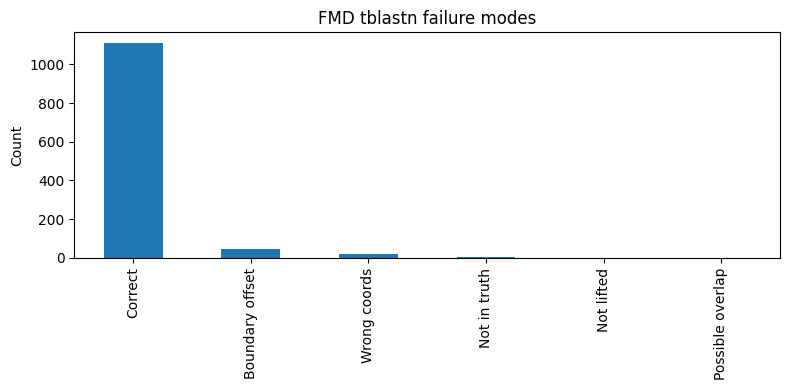

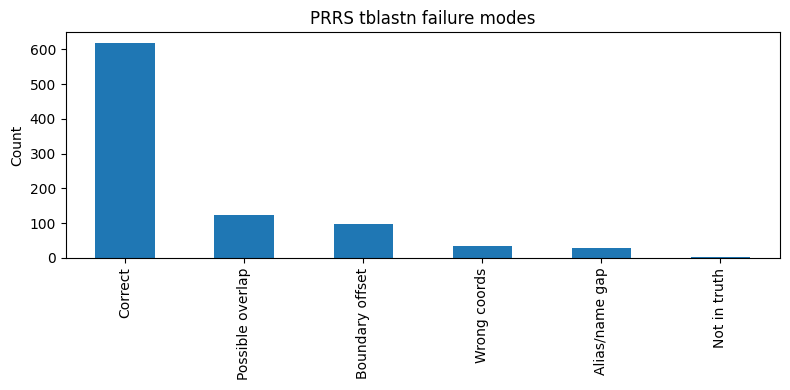

In [6]:
import matplotlib.pyplot as plt

for virus, sub in failure_modes.groupby('virus'):
    ax = sub.plot(kind='bar', x='failure_mode', y='count', legend=False, figsize=(8, 4))
    ax.set_title(f'{virus} tblastn failure modes')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.figure.tight_layout()
    ax.figure.savefig(OUTPUT_DIR / f'{virus.lower()}_tblastn_failure_modes.png', dpi=150)